# Chapter 09: Activation Functions (Sigmoid, Tanh, Softmax, & Cross-Entropy Probability Modeling)
<a href="https://colab.research.google.com/github/SatrioArjunaPutra/GrokkingDeepLearning/blob/main/Chapter%2009%20-%20Activation%20Functions/09_activation_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Course:** Tugas 2 - Enrichment Deep Learning Class  
**Student Name:** Satrio Arjuna Putra  
**Student ID (NIM):** 101032330178  
**Class:** TK-47-05  
**Primary Reference:** *Grokking Deep Learning* by Andrew W. Trask (Manning Publications)

---

## Chapter Objectives
In this chapter, we explore how neural networks model probabilities and non-linear representations using advanced activation functions:
1. **The Role of Activation Functions:** How non-linearities break linear subspace collapse and enable arbitrary function approximation.
2. **Deep-Dive Mathematical Analysis:** Deriving the functional forms and derivatives of **Sigmoid**, **Tanh**, **ReLU**, and **Leaky ReLU**.
3. **The Vanishing Gradient Dilemma:** Understanding why saturated activations impede backpropagation in deep architectures.
4. **Softmax & Cross-Entropy Loss:** Transforming raw unnormalized logits into calibrated probability distributions ($\sum \hat{y}_k = 1$) and deriving the remarkably clean gradient $\hat{\mathbf{y}} - \mathbf{y}$.
5. **Pure NumPy Scratch Implementation:** Constructing and training an MNIST classifier with Tanh hidden layers and Softmax cross-entropy output.

## 1. Concept & Theoretical Intuition

### 1.1 Activation Function Zoo & Mathematical Derivatives

#### 1. Sigmoid Function:
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$
* **Domain & Range:** Maps $\mathbb{R} \to (0, 1)$. Historically popular as an artificial firing probability.
* **Limitation:** Non-zero centered, and suffers from extreme gradient saturation (vanishing gradient when $|z| > 4$).

#### 2. Hyperbolic Tangent (Tanh):
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}, \quad \tanh'(z) = 1 - \tanh^2(z)$$
* **Domain & Range:** Maps $\mathbb{R} \to (-1, 1)$.
* **Advantage:** Zero-centered activations prevent directional zig-zagging during gradient descent. However, still saturates at extreme values.

#### 3. Rectified Linear Unit (ReLU):
$$f(z) = \max(0, z), \quad f'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \le 0 \end{cases}$$
* **Advantage:** Solves vanishing gradients for positive inputs; constant derivative of $1.0$ enables rapid convergence.

---

### 1.2 Softmax: Turning Raw Scores into Probability Distributions
In multi-class classification, raw linear outputs $\mathbf{z} = [z_0, z_1, \dots, z_{K-1}]$ (logits) can be negative or arbitrarily large. The **Softmax function** exponentiates and normalizes them into a legitimate categorical probability distribution:
$$P(y = k \mid \mathbf{x}) = \hat{y}_k = \frac{e^{z_k - \max(\mathbf{z})}}{\sum_{j=0}^{K-1} e^{z_j - \max(\mathbf{z})}}$$
*(Note: Subtracting $\max(\mathbf{z})$ provides numerical stability against exponential floating-point overflow).*

Properties of Softmax:
1. Strict positivity: $\hat{y}_k > 0 \quad \forall k$.
2. Unit simplex constraint: $\sum_{k=0}^{K-1} \hat{y}_k = 1.0$.

---

### 1.3 Categorical Cross-Entropy Loss & The Miracle Gradient
For a one-hot true label vector $\mathbf{y}$ and predicted distribution $\mathbf{\hat{y}}$:
$$\mathcal{L}_{\text{CE}} = -\sum_{k=0}^{K-1} y_k \ln(\hat{y}_k + \epsilon)$$
When differentiating Cross-Entropy with respect to the input logit $z_i$ through the Softmax function:
$$\frac{\partial \mathcal{L}_{\text{CE}}}{\partial z_i} = \sum_k \frac{\partial \mathcal{L}_{\text{CE}}}{\partial \hat{y}_k} \frac{\partial \hat{y}_k}{\partial z_i} = \hat{y}_i - y_i$$
In vector form:
$$\boldsymbol{\delta}_{\text{output}} = \mathbf{\hat{y}} - \mathbf{y}$$
Despite non-linear exponents and logarithms, the gradient of Softmax combined with Cross-Entropy collapses into the exact same intuitive difference: **prediction minus target**!

## 2. Scratch Implementation: Softmax & Tanh Neural Network

We build a complete neural network from scratch in pure NumPy:
* Hidden layer equipped with **Tanh** activation.
* Output layer equipped with **Softmax** probability distribution and **Cross-Entropy Loss**.
* Evaluated on MNIST handwritten digits.

In [1]:
import numpy as np
import os
import urllib.request

# Activation functions and derivatives
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1.0 - np.tanh(x) ** 2

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def softmax(z):
    # Numerically stable softmax
    shifted_z = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(shifted_z)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    eps = 1e-15
    y_pred_clipped = np.clip(y_pred, eps, 1.0 - eps)
    return -np.sum(y_true * np.log(y_pred_clipped)) / y_pred.shape[0]

# Load MNIST data
def load_mnist():
    dataset_path = 'mnist.npz'
    if not os.path.exists(dataset_path):
        url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
        urllib.request.urlretrieve(url, dataset_path)
    with np.load(dataset_path) as data:
        x_train, y_train = data['x_train'], data['y_train']
        x_test, y_test = data['x_test'], data['y_test']
    return (x_train, y_train), (x_test, y_test)

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist()

N_TRAIN = 2000
N_TEST = 500

X_train = x_train_raw[:N_TRAIN].reshape(N_TRAIN, 784) / 255.0
y_train = y_train_raw[:N_TRAIN]

X_test = x_test_raw[:N_TEST].reshape(N_TEST, 784) / 255.0
y_test = y_test_raw[:N_TEST]

# One-hot encode targets
Y_train = np.zeros((N_TRAIN, 10))
for i, val in enumerate(y_train):
    Y_train[i, val] = 1.0

Y_test = np.zeros((N_TEST, 10))
for i, val in enumerate(y_test):
    Y_test[i, val] = 1.0

print(f"Dataset ready: {N_TRAIN} train, {N_TEST} test.")

Dataset ready: 2000 train, 500 test.


In [2]:
print("=== Training Network: Tanh Hidden Layer + Softmax Cross-Entropy Output ===")
np.random.seed(42)

HIDDEN_DIM = 64
ALPHA = 0.05
EPOCHS = 25
BATCH_SIZE = 100

# Xavier / Glorot Initialization for Tanh
w_01 = np.random.randn(784, HIDDEN_DIM) * np.sqrt(2.0 / (784 + HIDDEN_DIM))
w_12 = np.random.randn(HIDDEN_DIM, 10) * np.sqrt(2.0 / (HIDDEN_DIM + 10))

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    correct = 0
    
    for b in range(0, N_TRAIN, BATCH_SIZE):
        batch_x = X_train[b:b+BATCH_SIZE]
        batch_y = Y_train[b:b+BATCH_SIZE]
        
        # 1. Forward pass
        z1 = batch_x.dot(w_01)
        a1 = tanh(z1)                     # Tanh activation
        z2 = a1.dot(w_12)
        y_hat = softmax(z2)               # Softmax probability distribution
        
        # 2. Loss & accuracy
        batch_loss = cross_entropy_loss(y_hat, batch_y)
        epoch_loss += batch_loss * batch_x.shape[0]
        correct += np.sum(np.argmax(y_hat, axis=1) == np.argmax(batch_y, axis=1))
        
        # 3. Backward pass (Miracle gradient: delta = y_hat - y)
        delta2 = (y_hat - batch_y) / BATCH_SIZE
        delta1 = delta2.dot(w_12.T) * tanh_deriv(z1)
        
        # 4. Gradient descent updates
        w_12 -= ALPHA * a1.T.dot(delta2)
        w_01 -= ALPHA * batch_x.T.dot(delta1)
        
    avg_train_loss = epoch_loss / N_TRAIN
    train_acc = (correct / N_TRAIN) * 100.0
    
    # Test set evaluation
    test_z1 = X_test.dot(w_01)
    test_a1 = tanh(test_z1)
    test_z2 = test_a1.dot(w_12)
    test_y_hat = softmax(test_z2)
    
    avg_test_loss = cross_entropy_loss(test_y_hat, Y_test)
    test_acc = np.mean(np.argmax(test_y_hat, axis=1) == y_test) * 100.0
    
    train_loss_history.append(avg_train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(avg_test_loss)
    test_acc_history.append(test_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

print(f"\nFinal Test Accuracy: {test_acc_history[-1]:.2f}%")

=== Training Network: Tanh Hidden Layer + Softmax Cross-Entropy Output ===
Epoch 01/25 | Train Loss: 1.8286 | Train Acc: 49.30% | Test Acc: 65.40%
Epoch 05/25 | Train Loss: 0.6858 | Train Acc: 85.30% | Test Acc: 81.60%


Epoch 10/25 | Train Loss: 0.4770 | Train Acc: 88.75% | Test Acc: 84.00%


Epoch 15/25 | Train Loss: 0.3918 | Train Acc: 90.35% | Test Acc: 87.20%
Epoch 20/25 | Train Loss: 0.3404 | Train Acc: 91.15% | Test Acc: 88.00%


Epoch 25/25 | Train Loss: 0.3039 | Train Acc: 92.30% | Test Acc: 88.60%

Final Test Accuracy: 88.60%


## 3. Visualizations & Analytical Plots

We now generate three essential analytical visualizations:
1. **Activation Functions & Derivatives Zoo:** Direct mathematical comparison of Sigmoid, Tanh, and ReLU.
2. **Cross-Entropy Loss & Accuracy Progression:** Convergence of our Softmax classifier.
3. **Calibrated Softmax Probabilities for a Sample Digit:** Showing how the network expresses confidence across all 10 candidate classes.

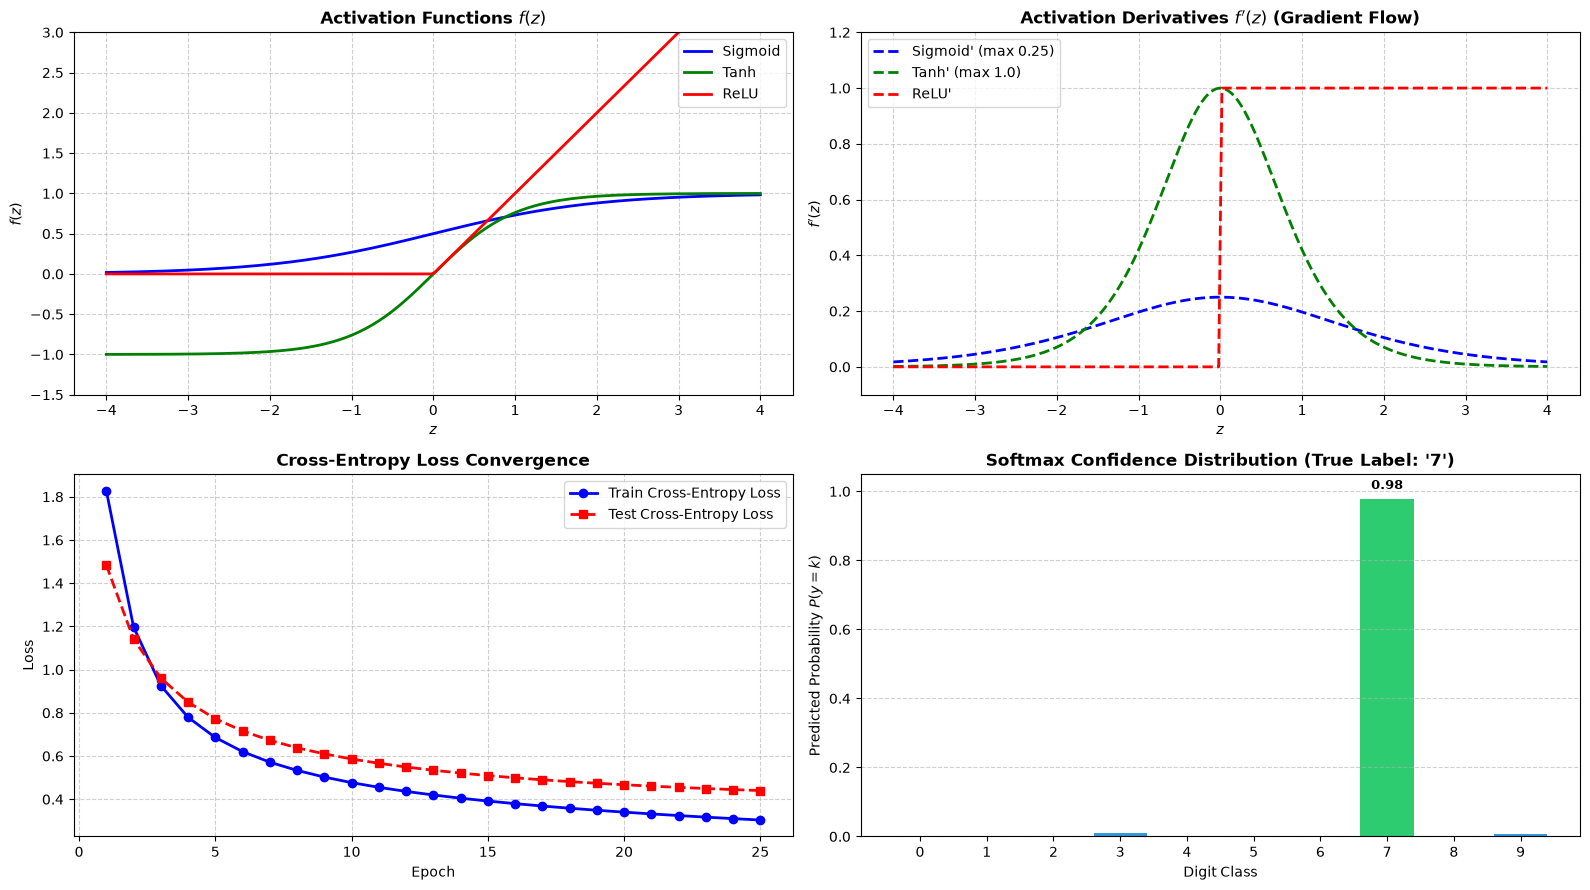

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 9))

# 1. Activation functions and derivatives
z_vals = np.linspace(-4, 4, 200)

ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(z_vals, sigmoid(z_vals), 'b-', linewidth=2, label='Sigmoid')
ax1.plot(z_vals, tanh(z_vals), 'g-', linewidth=2, label='Tanh')
ax1.plot(z_vals, relu(z_vals), 'r-', linewidth=2, label='ReLU')
ax1.set_title("Activation Functions $f(z)$", fontsize=12, fontweight='bold')
ax1.set_xlabel("$z$", fontsize=10)
ax1.set_ylabel("$f(z)$", fontsize=10)
ax1.set_ylim(-1.5, 3.0)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)

ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(z_vals, sigmoid_deriv(z_vals), 'b--', linewidth=2, label="Sigmoid' (max 0.25)")
ax2.plot(z_vals, tanh_deriv(z_vals), 'g--', linewidth=2, label="Tanh' (max 1.0)")
ax2.plot(z_vals, relu_deriv(z_vals), 'r--', linewidth=2, label="ReLU'")
ax2.set_title("Activation Derivatives $f'(z)$ (Gradient Flow)", fontsize=12, fontweight='bold')
ax2.set_xlabel("$z$", fontsize=10)
ax2.set_ylabel("$f'(z)$", fontsize=10)
ax2.set_ylim(-0.1, 1.2)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)

# 2. Loss Convergence
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(range(1, EPOCHS + 1), train_loss_history, 'b-o', linewidth=2, label='Train Cross-Entropy Loss')
ax3.plot(range(1, EPOCHS + 1), test_loss_history, 'r--s', linewidth=2, label='Test Cross-Entropy Loss')
ax3.set_title("Cross-Entropy Loss Convergence", fontsize=12, fontweight='bold')
ax3.set_xlabel("Epoch", fontsize=10)
ax3.set_ylabel("Loss", fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(fontsize=10)

# 3. Softmax Confidence Distribution for a Sample Digit
ax4 = fig.add_subplot(2, 2, 4)
sample_idx = 0
sample_img = X_test[sample_idx:sample_idx+1]
true_digit = y_test[sample_idx]
pred_probs = softmax(tanh(sample_img.dot(w_01)).dot(w_12))[0]

bars = ax4.bar(range(10), pred_probs, color=['#3498db' if i != true_digit else '#2ecc71' for i in range(10)])
ax4.set_title(f"Softmax Confidence Distribution (True Label: '{true_digit}')", fontsize=12, fontweight='bold')
ax4.set_xlabel("Digit Class", fontsize=10)
ax4.set_ylabel("Predicted Probability $P(y=k)$", fontsize=10)
ax4.set_xticks(range(10))
ax4.set_ylim(0, 1.05)
ax4.grid(True, linestyle='--', alpha=0.6, axis='y')

for bar in bars:
    yval = bar.get_height()
    if yval > 0.05:
        ax4.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Key Takeaway & Summary

1. **Activation Functions as Non-Linear Valves:**
   Without non-linear activations, multi-layer networks collapse algebraically into single linear models. Choosing the appropriate activation function depends on location: **ReLU/Tanh** for hidden layers to prevent gradient decay, and **Softmax** for classification outputs.
2. **Vanishing Gradient:**
   Sigmoid compresses inputs into $(0, 1)$ with a maximum derivative of $0.25$. Deep stacking of sigmoids attenuates gradients exponentially ($0.25^L \to 0$). Tanh offers zero-centered outputs and higher initial gradients ($1.0$), while ReLU avoids saturation entirely for positive activations.
3. **Softmax & Cross-Entropy Synergy:**
   Softmax maps arbitrary logits into true calibrated categorical probability distributions. When paired with categorical Cross-Entropy loss, the backpropagated output delta is the remarkably simple $\mathbf{\hat{y}} - \mathbf{y}$, ensuring optimal gradient dynamics without numerical instability.